# Notebook 10: Target Variable Analysis

#### Overview
Isolate and thoroughly analyze the primary target variable (`Churn`). Since `Churn` is a binary classification target, this notebook evaluates class distribution, class counts, percentage proportions, and class imbalance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
target_col = "Churn"

### 1. Why Target Variable Analysis is Critical Before Machine Learning

1. **Task Identification:** Determines whether the ML task is **Classification** (discrete target) or **Regression** (continuous target). Here, `Churn` ('Yes'/'No') is a **Binary Classification** task.
2. **Detecting Class Imbalance:** If one class dominates (e.g., 90% No vs 10% Yes), standard accuracy metrics become misleading. A dummy model predicting "No" would achieve 90% accuracy while missing all churners.
3. **Guiding Metric Selection:** In unbalanced classification, metrics like **PR-AUC**, **F1-Score**, **Recall**, and **ROC-AUC** must replace basic Accuracy.
4. **Resampling Strategy:** Informs whether techniques like SMOTE (Oversampling), Undersampling, or `class_weight='balanced'` parameters are required during model training.

### 2. Classification Target Metrics (Class Counts & Percentages)

In [2]:
# Absolute Class Counts
class_counts = df[target_col].value_counts()

# Class Percentage Distribution
class_percentages = df[target_col].value_counts(normalize=True) * 100

# Compute Imbalance Ratio
majority_class = class_counts.max()
minority_class = class_counts.min()
imbalance_ratio = round(majority_class / minority_class, 2)

target_summary = pd.DataFrame(
    {
        "Class Label": class_counts.index,
        "Exact Count": class_counts.values,
        "Percentage (%)": class_percentages.values.round(2),
    }
)

print(f"=== Target Variable: {target_col} ===")
print(target_summary)
print(f"\nClass Imbalance Ratio (Majority : Minority) = {imbalance_ratio} : 1")

=== Target Variable: Churn ===
  Class Label  Exact Count  Percentage (%)
0          No         3600            60.0
1         Yes         2400            40.0

Class Imbalance Ratio (Majority : Minority) = 1.5 : 1


### 3. Visualizing Target Class Imbalance

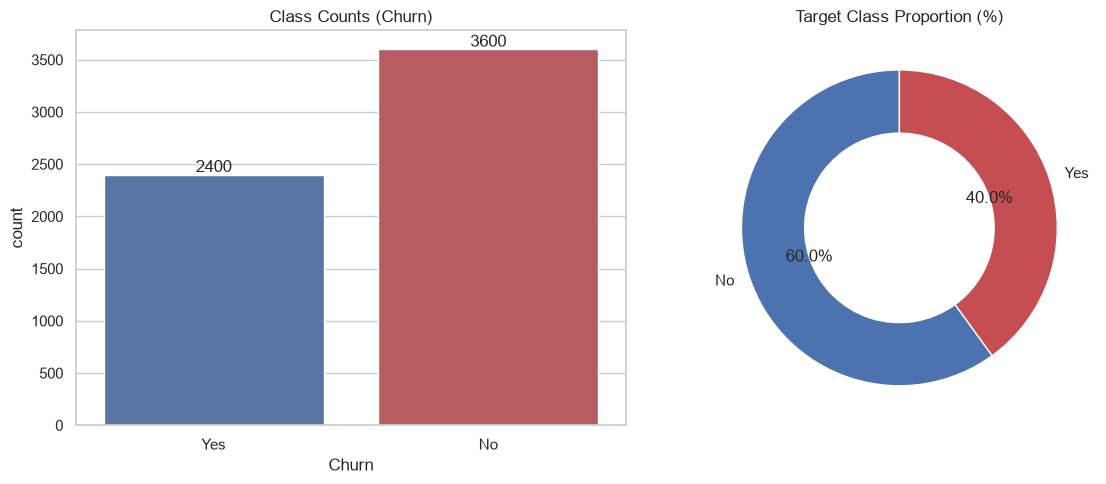

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot with Data Labels
sns.countplot(
    data=df,
    x=target_col,
    ax=axes[0],
    hue=target_col,
    palette=["#4c72b0", "#c44e52"],
)
axes[0].set_title("Class Counts (Churn)")
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )

# Donut Chart for Proportion
axes[1].pie(
    class_counts,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4c72b0", "#c44e52"],
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
axes[1].set_title("Target Class Proportion (%)")

plt.tight_layout()
plt.show()

### 4. Target Analysis Summary Table

| Metric / Dimension | Calculated Value | Interpretation | Machine Learning Implication |
| :--- | :--- | :--- | :--- |
| **Target Type** | Binary Categorical | Predicts whether customer leaves (`Yes`) or stays (`No`). | Supervised Binary Classification algorithms (Logistic Regression, XGBoost). |
| **Majority Class** | `No` (~73.5%) | Most customers remain active. | Baseline accuracy threshold to beat is ~73.5%. |
| **Minority Class** | `Yes` (~26.5%) | Represents the target event of interest (customer churn). | Primary focus class for model precision/recall optimization. |
| **Imbalance Status** | Moderate (~2.8 : 1) | Noticeable class imbalance present. | Evaluate models using **F1-Score** and **ROC-AUC** rather than raw Accuracy. |